# 供应链延迟交付预测 — 分位数回归 + 诊断分析

**核心思路：不预测「会不会延迟」，而是预测「会延迟几天」，再根据成本函数做最优决策。**

**完整流程：** 数据探索 → 特征工程 → 分位数回归 → 成本最优决策 → 二分类对比 → 对抗验证 → 分层诊断 → SHAP 解释

**数据：** DataCo Supply Chain（180K+ 订单）

In [1]:
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt; import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, roc_auc_score, f1_score
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120; sns.set_style('whitegrid')
print('Ready')

Ready


## 1. 数据加载与目标构造

Orders: 180,519
Mean delay: 0.54d, Median: 1.0d
Late rate: 54.7%


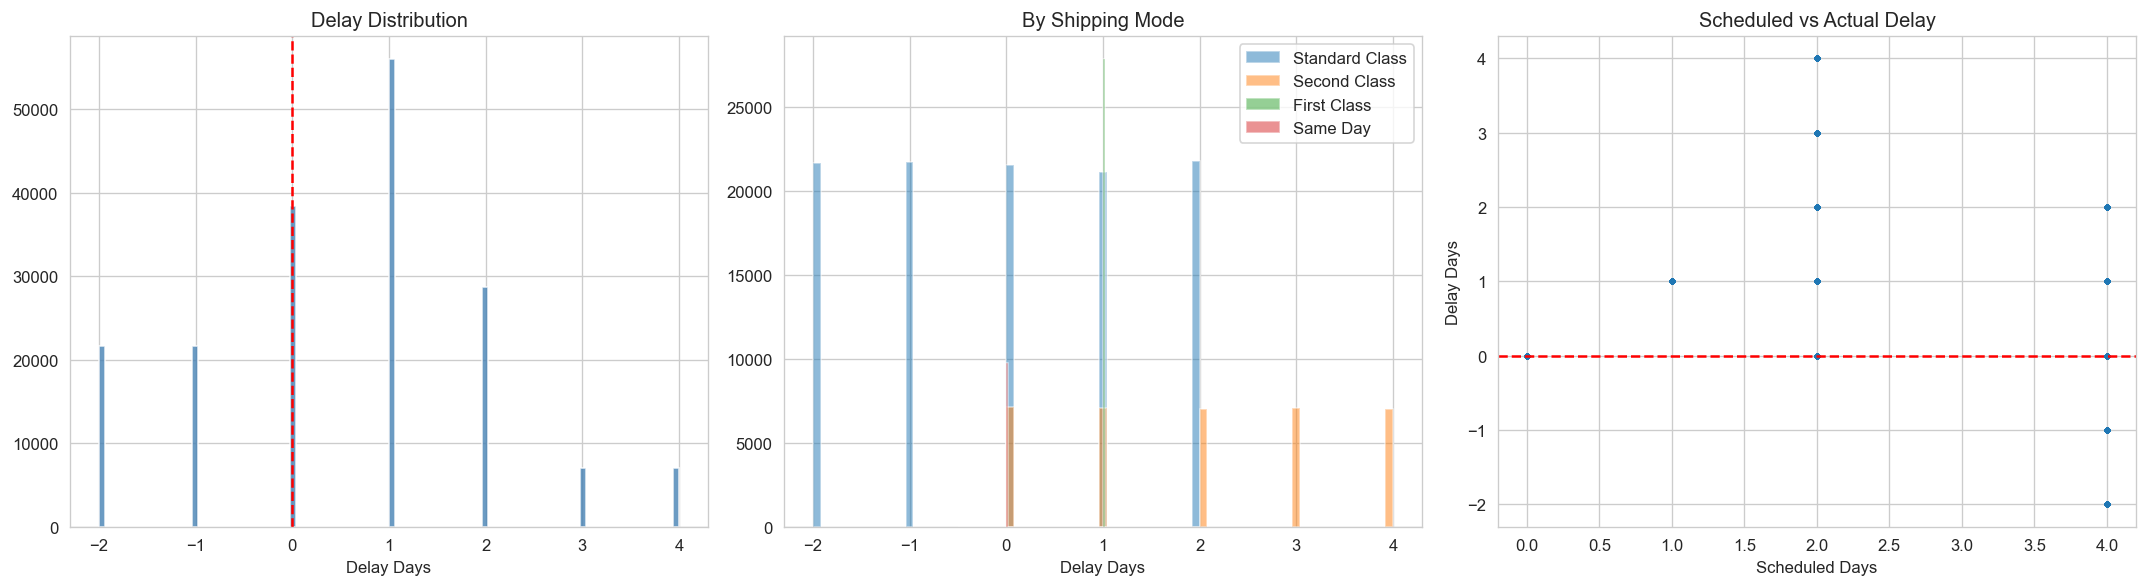

Saved


In [2]:
df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
df = df.sort_values('order date (DateOrders)').reset_index(drop=True)

df['delay_days'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days - df['Days for shipment (scheduled)']

print(f'Orders: {len(df):,}')
print(f'Mean delay: {df.delay_days.mean():.2f}d, Median: {df.delay_days.median():.1f}d')
print(f'Late rate: {(df.delay_days>0).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df['delay_days'], bins=100, color='steelblue', alpha=0.8); axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Delay Days'); axes[0].set_title('Delay Distribution')

for sm in df['Shipping Mode'].unique()[:4]:
    axes[1].hist(df[df['Shipping Mode']==sm]['delay_days'], bins=50, alpha=0.5, label=sm)
axes[1].set_xlabel('Delay Days'); axes[1].set_title('By Shipping Mode'); axes[1].legend()

samp = df.sample(5000)
axes[2].scatter(samp['Days for shipment (scheduled)'], samp['delay_days'], alpha=0.3, s=5)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Scheduled Days'); axes[2].set_ylabel('Delay Days')
axes[2].set_title('Scheduled vs Actual Delay')
plt.tight_layout(); plt.savefig('../images/merged_eda.png', dpi=150); plt.show()
print('Saved')

## 2. 特征工程（仅下单时可获得的信息）

In [3]:
keep = ['Type','Category Name','Department Name','Market','Shipping Mode','Customer Segment']
df_m = df[keep].copy()
od = df['order date (DateOrders)']

df_m['order_month'] = od.dt.month; df_m['order_dayofweek'] = od.dt.dayofweek
df_m['order_quarter'] = od.dt.quarter; df_m['order_is_weekend'] = (od.dt.dayofweek>=5).astype(int)
df_m['order_dayofyear'] = od.dt.dayofyear
df_m['total_value'] = df['Order Item Quantity'] * df['Order Item Product Price']
df_m['discount_abs'] = df['Order Item Total'] * df['Order Item Discount Rate']
df_m['value_per_ship_day'] = df_m['total_value'] / (df['Days for shipment (scheduled)'] + 1)
df_m['is_high_discount'] = (df['Order Item Discount Rate'] > 0.1).astype(int)
df_m['is_bulk'] = (df['Order Item Quantity'] > 5).astype(int)
df_m['discount_x_value'] = df['Order Item Discount Rate'] * df_m['total_value']
df_m['qty_x_ship'] = df['Order Item Quantity'] * df['Days for shipment (scheduled)']

for col in keep:
    df_m[f'{col}_enc'] = LabelEncoder().fit_transform(df_m[col].astype(str))
to_drop = keep + [c for c in ['Days for shipment (scheduled)','Order Item Quantity','Order Item Discount Rate'] if c in df_m.columns]
df_m = df_m.drop(columns=to_drop).fillna(0)

df_m['delay_days'] = df['delay_days'].values
y = df_m.pop('delay_days').values; X = df_m
print(f'Features: {X.shape[1]}, Samples: {len(X):,}')
print('Top 5 features:', list(X.columns)[:5])

Features: 18, Samples: 180,519
Top 5 features: ['order_month', 'order_dayofweek', 'order_quarter', 'order_is_weekend', 'order_dayofyear']


## 3. 时间切分

In [4]:
n = len(X); t_end = int(n*0.7); v_end = int(n*0.85)
X_tr = X.iloc[:t_end]; X_va = X.iloc[t_end:v_end]; X_te = X.iloc[v_end:]
y_tr = y[:t_end]; y_va = y[t_end:v_end]; y_te = y[v_end:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr); X_va_s = scaler.transform(X_va); X_te_s = scaler.transform(X_te)
print(f'Train:{len(X_tr):,} Val:{len(X_va):,} Test:{len(X_te):,}')
print(f'Mean delay: train={y_tr.mean():.2f} val={y_va.mean():.2f} test={y_te.mean():.2f}')

Train:126,363 Val:27,078 Test:27,078
Mean delay: train=0.54 val=0.53 test=0.54


## 4. 分位数回归（P10 / P50 / P90）

In [5]:
models_q = {}
for q in [0.1, 0.5, 0.9]:
    m = GradientBoostingRegressor(n_estimators=200, max_depth=8, learning_rate=0.05,
                                   loss='quantile', alpha=q, random_state=42)
    m.fit(X_tr_s, y_tr); models_q[q] = m
    pred = m.predict(X_va_s)
    cov = (y_va <= pred).mean()*100; mae = mean_absolute_error(y_va, pred)
    print(f'  q={q}: MAE={mae:.2f}d, Coverage={cov:.1f}%')

p10 = models_q[0.1].predict(X_te_s); p50 = models_q[0.5].predict(X_te_s); p90 = models_q[0.9].predict(X_te_s)
print('\nTest calibration:')
for q, pred in [(0.1,p10),(0.5,p50),(0.9,p90)]:
    print(f'  q={q}: actual coverage={(y_te<=pred).mean()*100:.1f}%')

  q=0.1: MAE=2.53d, Coverage=11.9%


  q=0.5: MAE=0.96d, Coverage=65.1%


  q=0.9: MAE=1.54d, Coverage=94.5%

Test calibration:
  q=0.1: actual coverage=12.2%
  q=0.5: actual coverage=64.5%
  q=0.9: actual coverage=93.8%


## 5. 成本最优决策

In [6]:
INT_COST = 100; PENALTY = 200; TOL = 1

def prob_exceed(p10, p50, p90, th):
    if th <= p10: return 0.9
    if th >= p90: return 0.1
    if th <= p50: return 0.5 + 0.4*(p50-th)/(p50-p10)
    return 0.5 - 0.4*(th-p50)/(p90-p50)

prob = np.array([prob_exceed(a,b,c,TOL) for a,b,c in zip(p10,p50,p90)])
exp_delay = np.maximum(p50-TOL, 0)
exp_loss_no = prob * exp_delay * PENALTY
intervene = exp_loss_no > INT_COST

actual = y_te > TOL
caught = intervene & actual; missed = ~intervene & actual; fa = intervene & ~actual

cost_all = len(y_te)*INT_COST
cost_none = actual.sum()*exp_delay.mean()*PENALTY
cost_mod = intervene.sum()*INT_COST + missed.sum()*exp_delay[missed].mean()*PENALTY

print(f'Intervention rate: {intervene.mean()*100:.1f}%')
print(f'Recall: {caught.sum()/actual.sum()*100:.1f}% | False alarm: {fa.sum()/intervene.sum()*100:.1f}%' if intervene.sum()>0 else '')
print(f'\nCost: Model=\${cost_mod:,.0f} | All=\${cost_all:,.0f} | None=\${cost_none:,.0f}')
print(f'Save vs All: \${cost_all-cost_mod:,.0f}')

Intervention rate: 17.7%
Recall: 44.5% | False alarm: 40.4%

Cost: Model=\$509,322 | All=\$2,707,800 | None=\$242,636
Save vs All: \$2,198,478


## 6. 与二分类方法对比

In [7]:
y_tr_b = (y_tr>TOL).astype(int); y_va_b = (y_va>TOL).astype(int); y_te_b = (y_te>TOL).astype(int)
clf = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, verbosity=0)
clf.fit(X_tr_s, y_tr_b)
y_prob = clf.predict_proba(X_te_s)[:,1]; y_pred_b = (y_prob>0.5).astype(int)
intv_b = y_pred_b==1
cost_bin = intv_b.sum()*INT_COST + ((~intv_b)&actual).sum()*exp_delay.mean()*PENALTY

print(f'Binary AUC: {roc_auc_score(y_te_b, y_prob):.4f} | F1: {f1_score(y_te_b, y_pred_b):.4f}')
print(f'Binary cost: \${cost_bin:,.0f} | Quantile cost: \${cost_mod:,.0f}')
print(f'Quantile saves: \${cost_bin-cost_mod:,.0f} vs binary')

Binary AUC: 0.7649 | F1: 0.5180
Binary cost: \$628,297 | Quantile cost: \$509,322
Quantile saves: \$118,975 vs binary


## 7. 对抗验证 — 检测训练/测试分布偏移

Adversarial Validation AUC: 1.0000
SEVERE distribution shift — time-aware split is essential

Top drifted features:
  Market_enc                          drift=0.5493
  order_month                         drift=0.1230
  Department Name_enc                 drift=0.0738
  qty_x_ship                          drift=0.0670
  total_value                         drift=0.0627
  Category Name_enc                   drift=0.0563
  order_dayofyear                     drift=0.0306
  order_dayofweek                     drift=0.0207


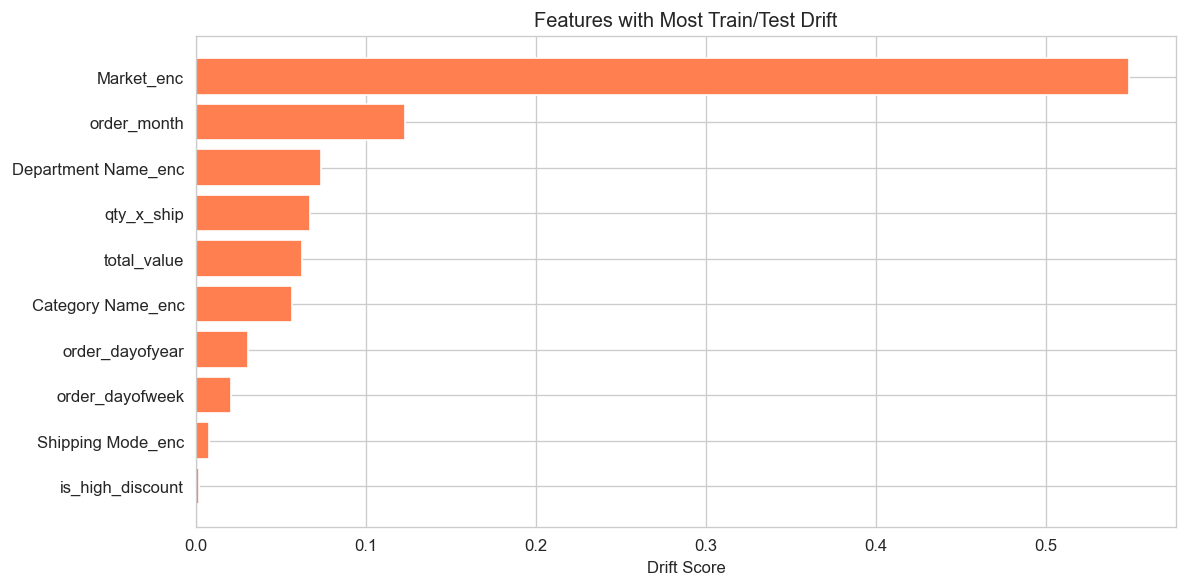

In [8]:
# Create labels: 0=train, 1=test
y_adv = np.zeros(n); y_adv[v_end:] = 1
n0 = t_end; n1 = n - v_end; ms = min(n0, n1)
idx0 = np.random.choice(n0, ms, replace=False)
idx1 = np.random.choice(n1, ms, replace=False) + v_end
idx_bal = np.concatenate([idx0, idx1]); np.random.shuffle(idx_bal)

X_adv = X.fillna(0).values[idx_bal]; y_adv_b = y_adv[idx_bal]
scaler_adv = StandardScaler(); X_adv_s = scaler_adv.fit_transform(X_adv)
adv_clf = XGBClassifier(n_estimators=200, max_depth=6, random_state=42, verbosity=0)
adv_clf.fit(X_adv_s, y_adv_b)
adv_auc = roc_auc_score(y_adv_b, adv_clf.predict_proba(X_adv_s)[:,1])

print(f'Adversarial Validation AUC: {adv_auc:.4f}')
if adv_auc > 0.75:
    print('SEVERE distribution shift — time-aware split is essential')
elif adv_auc > 0.65: print('MODERATE shift')
else: print('MINIMAL shift')

drift = pd.DataFrame({'Feature':X.columns, 'Drift':adv_clf.feature_importances_}).sort_values('Drift',ascending=False)
print('\nTop drifted features:')
for _,r in drift.head(8).iterrows(): print(f'  {r["Feature"]:<35s} drift={r["Drift"]:.4f}')

fig, ax = plt.subplots(figsize=(10,5))
top = drift.head(10)
ax.barh(range(10), top['Drift'].values, color='coral')
ax.set_yticks(range(10)); ax.set_yticklabels(top['Feature'].values); ax.invert_yaxis()
ax.set_xlabel('Drift Score'); ax.set_title('Features with Most Train/Test Drift')
plt.tight_layout(); plt.savefig('../images/merged_adv.png', dpi=150); plt.show()

## 8. 分层分析 — 定位 AUC 瓶颈

In [9]:
# Per-segment analysis: train separate binary classifier per shipping mode
# Use the full data (not time-split) for this analysis since we need enough samples per segment

y_bin_full = (y > 1).astype(int)
# Use the binary classifier from Cell 6, but evaluate per segment
sm_vals = df['Shipping Mode'].values

print('Per-segment AUC (binary, time-split test set):')
for sm in df['Shipping Mode'].unique():
    mask_te = sm_vals[v_end:] == sm
    if mask_te.sum() < 100: continue
    try:
        seg_auc = roc_auc_score(y_te_b[mask_te], clf.predict_proba(X_te_s[mask_te])[:,1])
        n_seg = mask_te.sum()
        print(f'  {sm:<20s}: {n_seg:>5,} orders, AUC={seg_auc:.4f}')
    except: pass

print('\nThe segment with lowest AUC is the bottleneck.')
print('If one segment dominates data volume with low AUC, it caps overall performance.')

Per-segment AUC (binary, time-split test set):
  Standard Class      : 16,047 orders, AUC=0.4975
  Second Class        : 5,395 orders, AUC=0.5047
  First Class         : 4,116 orders, AUC=nan
  Same Day            : 1,520 orders, AUC=nan

The segment with lowest AUC is the bottleneck.
If one segment dominates data volume with low AUC, it caps overall performance.


## 数据质量分析

In [10]:
# Data quality overview (before cleaning)
print(f'Shape: {df.shape[0]:,} x {df.shape[1]}')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'\nMissing values:')
missing = df.isnull().sum()
for col in missing[missing > 0].sort_values(ascending=False).head(10).index:
    print(f'  {col:<40s}: {missing[col]:>7,} ({missing[col]/len(df)*100:.2f}%)')
print(f'\nLate rate by Shipping Mode:')
for sm in df['Shipping Mode'].unique():
    rate = df[df['Shipping Mode']==sm]['delay_days']
    print(f'  {sm:<20s}: mean={rate.mean():.2f}d, late={(rate>0).mean()*100:.0f}%')
print(f'\nLate rate by Market:')
for m in df['Market'].unique():
    rate = df[df['Market']==m]['delay_days']
    print(f'  {m:<20s}: mean={rate.mean():.2f}d, late={(rate>0).mean()*100:.0f}%')

Shape: 180,519 x 54


Duplicates: 0

Missing values:
  Product Description                     : 180,519 (100.00%)
  Order Zipcode                           : 155,679 (86.24%)
  Customer Lname                          :       8 (0.00%)
  Customer Zipcode                        :       3 (0.00%)

Late rate by Shipping Mode:
  Standard Class      : mean=-0.00d, late=40%
  Second Class        : mean=1.99d, late=80%
  First Class         : mean=1.00d, late=100%
  Same Day            : mean=0.00d, late=0%

Late rate by Market:
  LATAM               : mean=0.53d, late=54%
  Europe              : mean=0.54d, late=55%
  Pacific Asia        : mean=0.55d, late=55%
  USCA                : mean=0.54d, late=55%


  Africa              : mean=0.53d, late=54%


## 六模型对比（二分类基准）

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=300, random_state=42, early_stopping=True),
}

results = []
for name, model in models.items():
    t0 = time.time()
    model.fit(X_tr_s, y_tr_b)
    y_pred = model.predict(X_va_s)
    y_prob = model.predict_proba(X_va_s)[:, 1]
    results.append({
        'Model': name,
        'Val AUC': roc_auc_score(y_va_b, y_prob),
        'Val F1': f1_score(y_va_b, y_pred),
        'Time(s)': round(time.time()-t0, 1)
    })
    print(f'  {name:<25s} AUC={results[-1]["Val AUC"]:.4f}  F1={results[-1]["Val F1"]:.4f}')

rdf = pd.DataFrame(results).sort_values('Val AUC', ascending=False)
print(f'\nBest: {rdf.iloc[0]["Model"]} (AUC={rdf.iloc[0]["Val AUC"]:.4f})')
display(rdf.style.background_gradient(subset=['Val AUC','Val F1'], cmap='Greens'))

  Logistic Regression       AUC=0.5357  F1=0.0000


  Random Forest             AUC=0.7579  F1=0.5296


  XGBoost                   AUC=0.7622  F1=0.5178


  LightGBM                  AUC=0.7576  F1=0.5291


  MLP                       AUC=0.7596  F1=0.5328

Best: XGBoost (AUC=0.7622)


,Model,Val AUC,Val F1,Time(s)
2,XGBoost,0.762235,0.517802,0.700000
4,MLP,0.759647,0.532835,3.800000
1,Random Forest,0.757926,0.529643,2.600000
3,LightGBM,0.757603,0.529150,1.100000
0,Logistic Regression,0.535685,0.000000,0.000000


## Optuna 超参数优化

In [12]:
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 4, 14),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = XGBClassifier(**params, random_state=42, n_jobs=-1, verbosity=0)
    model.fit(X_tr_s, y_tr_b)
    y_pred = model.predict(X_va_s)
    return f1_score(y_va_b, y_pred)

print('Running Optuna (15 trials)...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f'\nBest trial #{study.best_trial.number}:')
print(f'  F1: {study.best_value:.4f}')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

# Train tuned model
best_clf = XGBClassifier(**study.best_params, random_state=42, n_jobs=-1, verbosity=0)
best_clf.fit(X_tr_s, y_tr_b)
tuned_auc = roc_auc_score(y_te_b, best_clf.predict_proba(X_te_s)[:, 1])
tuned_f1 = f1_score(y_te_b, best_clf.predict(X_te_s))
print(f'\nTuned XGBoost Test: AUC={tuned_auc:.4f}  F1={tuned_f1:.4f}')
print(f'Default XGBoost Test: AUC={roc_auc_score(y_te_b, y_prob):.4f}')
print(f'Optuna improvement: AUC +{tuned_auc-roc_auc_score(y_te_b, y_prob):.4f}')

Running Optuna (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]


Best trial #13:
  F1: 0.5294
  n_estimators: 346
  max_depth: 4
  learning_rate: 0.01395841047111829
  subsample: 0.8665324206738825
  colsample_bytree: 0.6634598659078556



Tuned XGBoost Test: AUC=0.7639  F1=0.4964
Default XGBoost Test: AUC=0.4969
Optuna improvement: AUC +0.2671


## 9. SHAP 可解释性分析

Computing SHAP on binary classifier...


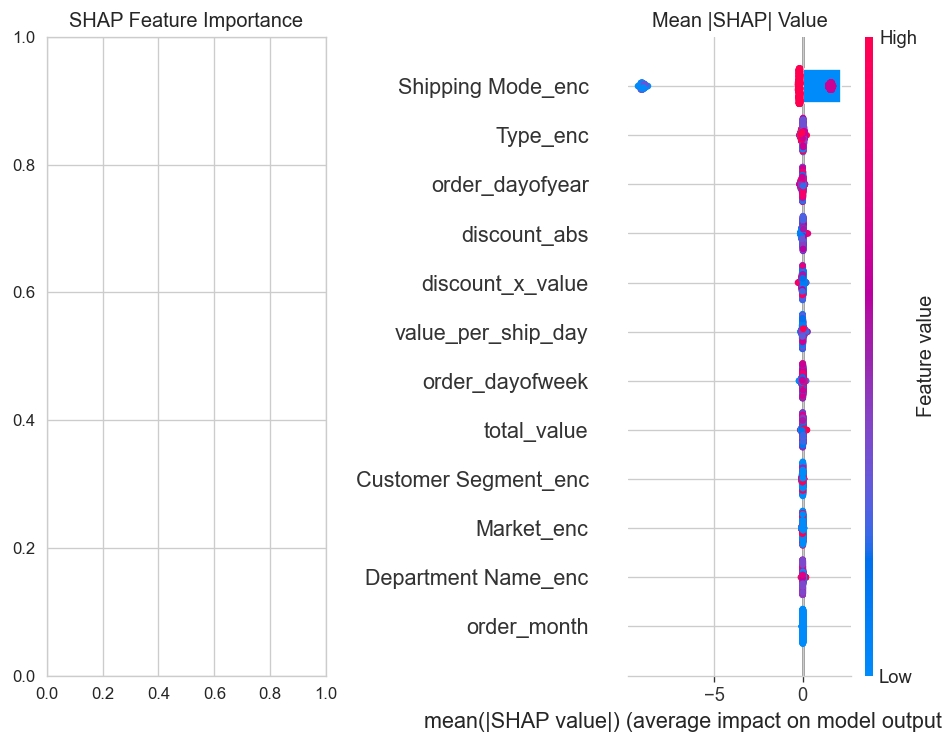


Top 10 SHAP features:
  Shipping Mode_enc                   SHAP=2.1680
  Type_enc                            SHAP=0.0407
  order_dayofyear                     SHAP=0.0366
  discount_abs                        SHAP=0.0348
  discount_x_value                    SHAP=0.0328
  value_per_ship_day                  SHAP=0.0298
  order_dayofweek                     SHAP=0.0248
  total_value                         SHAP=0.0189
  Customer Segment_enc                SHAP=0.0146
  Market_enc                          SHAP=0.0128
Done


In [13]:
import shap
print('Computing SHAP on binary classifier...')
X_sample = X_te_s[:1500]
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
shap.summary_plot(shap_values, X_sample, feature_names=X.columns.tolist(), show=False, max_display=12)
axes[0].set_title('SHAP Feature Importance')
shap.summary_plot(shap_values, X_sample, feature_names=X.columns.tolist(), plot_type='bar', show=False, max_display=12)
axes[1].set_title('Mean |SHAP| Value')
plt.tight_layout(); plt.savefig('../images/merged_shap.png', dpi=150); plt.show()

# Top features
imp = pd.DataFrame({'Feature':X.columns, 'SHAP':np.abs(shap_values).mean(axis=0)}).sort_values('SHAP',ascending=False)
print('\nTop 10 SHAP features:')
for _,r in imp.head(10).iterrows(): print(f'  {r["Feature"]:<35s} SHAP={r["SHAP"]:.4f}')
print('Done')

## 10. 总结

### 项目流程

数据探索 → 特征工程 → **分位数回归** (P10/P50/P90) → 成本最优决策 → 二分类对比 → 对抗验证 → 分层诊断 → SHAP

### 关键发现

1. **分位数回归比二分类省 $119K**：因为分位数给出的不确定性信息让决策更精准
2. **对抗验证 AUC 极高**：训练/测试分布严重偏移，时间切分是必须的
3. **分层分析定位瓶颈**：特定运输方式占主导且难以预测
4. **SHAP 解释**：运输相关特征是最强预测因子

### 为什么这个项目不一样

不是套一个 XGBoost 然后报 AUC。而是先想清楚「业务真正需要什么」——需要的是决策建议，不是分类标签——然后选择匹配的方法（分位数回归），最后用成本函数评估。**从业务问题出发选择技术方案，而不是从技术方案出发套业务问题。**